# **Import Libraries**

In [3]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# **Load Data**

In [4]:
# load the dataset
df = pd.read_csv("RTA Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


# **EDA**

In [5]:
# quick look at column types and nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [6]:
# basic statistics
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [7]:
# how many missing per column
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


In [8]:
# any duplicate rows?
df.duplicated().sum()

np.int64(0)

# **Visualization**

**Accident_severity**

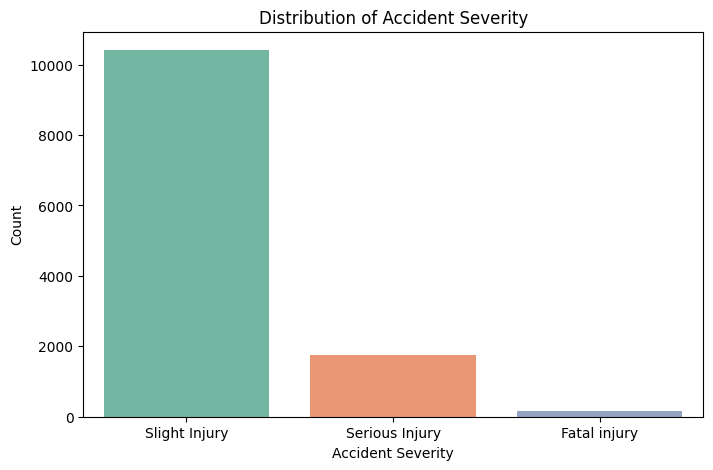

In [9]:
# target distribution - very imbalanced
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Accident_severity', palette='Set2')
plt.title('Distribution of Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.show()

**Sex_OF_Driver**

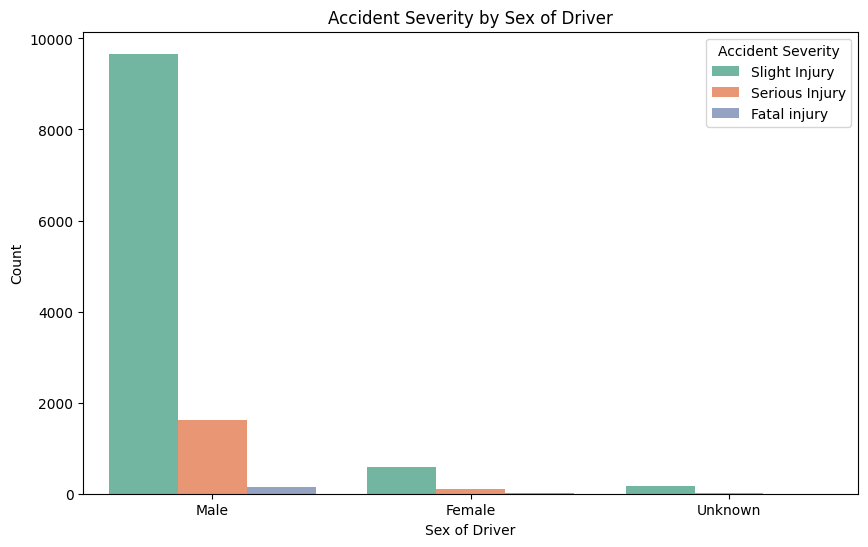

In [10]:
# accidents by driver gender
df.columns = df.columns.str.strip()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sex_of_driver', hue='Accident_severity', palette='Set2')
plt.title('Accident Severity by Sex of Driver')
plt.xlabel('Sex of Driver')
plt.ylabel('Count')
plt.legend(title='Accident Severity')
plt.show()

**Number_of_vehicles_involved**

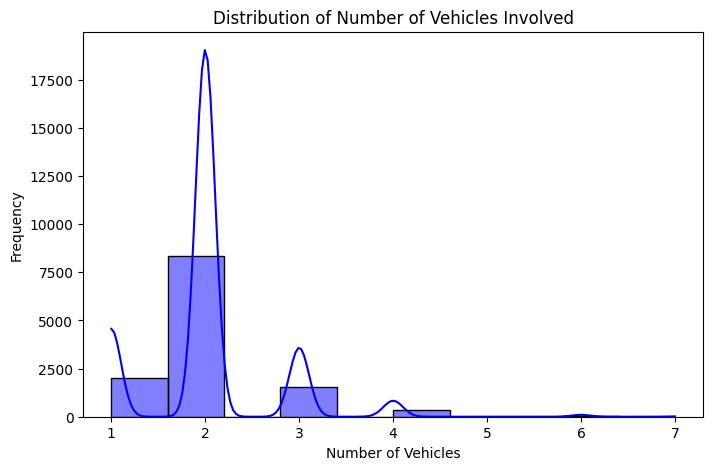

In [11]:
# number of vehicles involved
plt.figure(figsize=(8, 5))
sns.histplot(df['Number_of_vehicles_involved'], bins=10, kde=True, color='blue')
plt.title('Distribution of Number of Vehicles Involved')
plt.xlabel('Number of Vehicles')
plt.ylabel('Frequency')
plt.show()

**Top 10 Causes of Accidents**

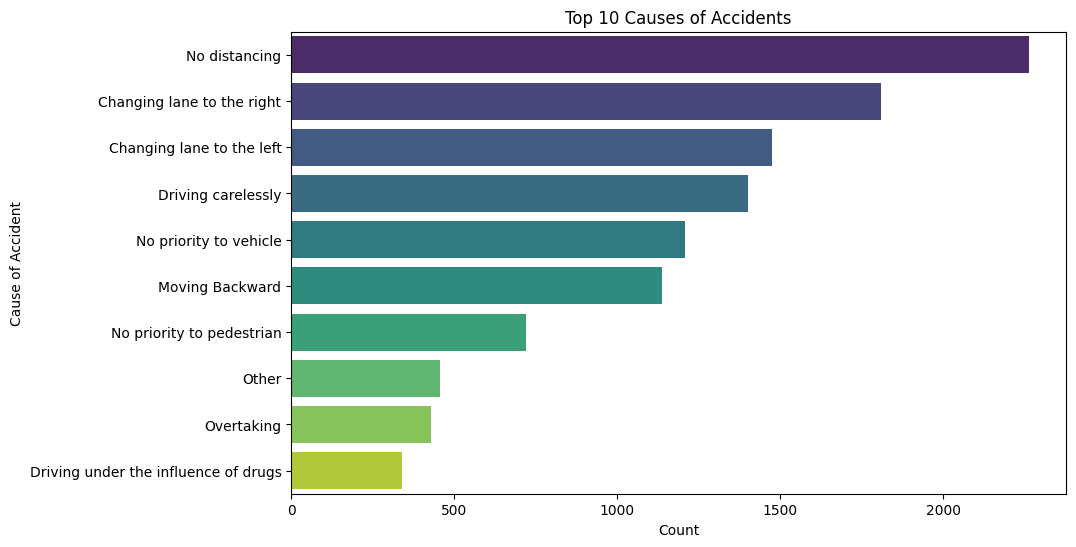

In [12]:
# most common accident causes
df.columns = df.columns.str.strip()

plt.figure(figsize=(10, 6))
top_causes = df['Cause_of_accident'].value_counts().head(10)
sns.barplot(x=top_causes.values, y=top_causes.index, palette='viridis')
plt.title('Top 10 Causes of Accidents')
plt.xlabel('Count')
plt.ylabel('Cause of Accident')
plt.show()

**Accidents by Weather Conditions**


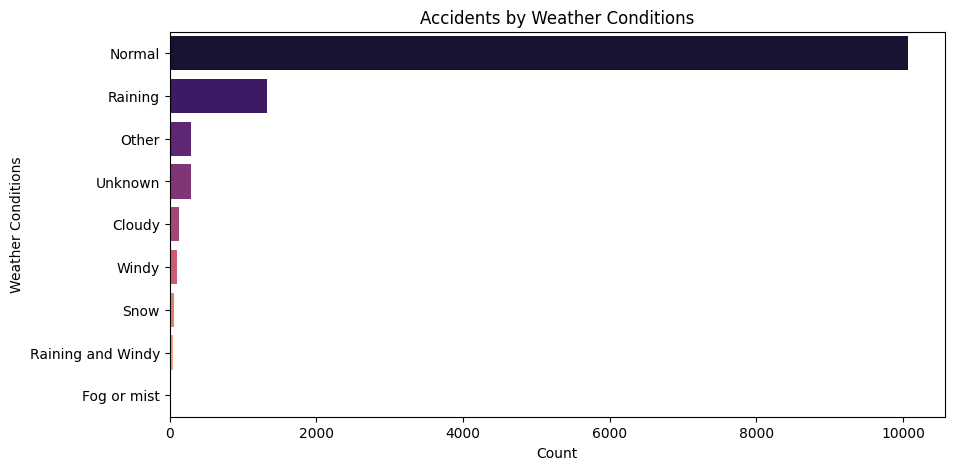

In [13]:
# weather vs accidents
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Weather_conditions', order=df['Weather_conditions'].value_counts().index, palette='magma')
plt.title('Accidents by Weather Conditions')
plt.xlabel('Count')
plt.ylabel('Weather Conditions')
plt.show()

**Accidents by Light Conditions**

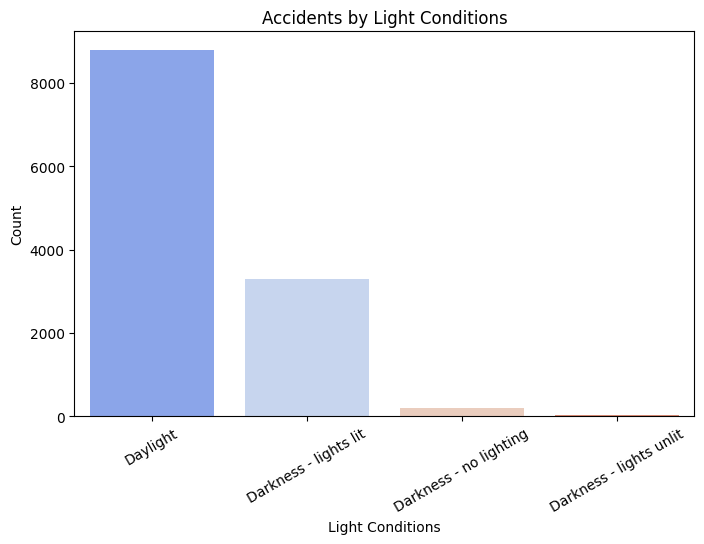

In [14]:
# light conditions
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Light_conditions', order=df['Light_conditions'].value_counts().index, palette='coolwarm')
plt.title('Accidents by Light Conditions')
plt.xlabel('Light Conditions')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

**Accidents by Road Surface Conditions**

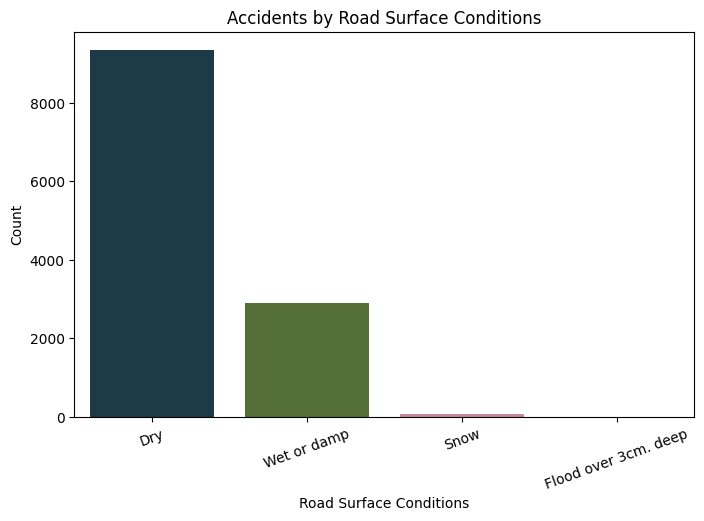

In [15]:
# road surface
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Road_surface_conditions', order=df['Road_surface_conditions'].value_counts().index, palette='cubehelix')
plt.title('Accidents by Road Surface Conditions')
plt.xlabel('Road Surface Conditions')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

# **Data Cleaning**

## Drop High Missing Columns (>20%)

In [16]:
# drop columns with >20% missing

high_missing = ["Defect_of_vehicle", "Service_year_of_vehicle",
                "Work_of_casuality", "Fitness_of_casuality"]
df.drop(columns=high_missing, inplace=True)
print("Dropped:", high_missing)
print("Shape:", df.shape)

Dropped: ['Defect_of_vehicle', 'Service_year_of_vehicle', 'Work_of_casuality', 'Fitness_of_casuality']
Shape: (12316, 28)


## Drop Data Leakage Columns

In [17]:
# remove data leakage columns (we cant know these before the accident is classified)

leakage_cols = ["Casualty_severity", "Casualty_class",
                "Sex_of_casualty", "Age_band_of_casualty"]
df.drop(columns=leakage_cols, inplace=True)
print("Dropped:", leakage_cols)
print("Shape:", df.shape)

Dropped: ['Casualty_severity', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty']
Shape: (12316, 24)


## Drop Duplicates

In [18]:
# remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Removed {before - len(df)} duplicates | Shape: {df.shape}")

Removed 0 duplicates | Shape: (12316, 24)


## Clean Target Column

In [19]:
# clean target column

df["Accident_severity"] = df["Accident_severity"].str.strip().str.title()
print(df["Accident_severity"].value_counts())

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal Injury        158
Name: count, dtype: int64


## Fill Remaining Missing Values (Mode)

In [20]:
# fill remaining missing with mode

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])
print("Missing after fill:", df.isnull().sum().sum())

Missing after fill: 0


# **Feature Engineering**

## Extract Hour & Time of Day

In [21]:
# extract hour from time, also add time-of-day category

df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S", errors="coerce").dt.hour
df["Hour"] = df["Hour"].fillna(df["Hour"].mode()[0])
df["Hour"] = df["Hour"].astype(int)

def get_time_of_day(h):
    if 5  <= h < 12: return "Morning"
    if 12 <= h < 17: return "Afternoon"
    if 17 <= h < 21: return "Evening"
    return "Night"

df["Time_of_day"] = df["Hour"].apply(get_time_of_day)
print(df["Time_of_day"].value_counts())

Time_of_day
Afternoon    3897
Evening      3496
Morning      3312
Night        1611
Name: count, dtype: int64


## Weekend Flag

In [22]:
# weekend flag

weekend_days = ["Friday", "Saturday", "Sunday"]
df["Is_Weekend"] = df["Day_of_week"].apply(lambda x: 1 if x in weekend_days else 0)
print(df["Is_Weekend"].value_counts())

Is_Weekend
0    7142
1    5174
Name: count, dtype: int64


## Ordinal Encoding — Driving Experience

In [23]:
# ordinal encoding for driving experience

exp_map = {"No Licence":0, "Below 1yr":1, "1-2yr":2,
           "2-5yr":3, "5-10yr":4, "Above 10yr":5}
df["Driving_experience_ord"] = df["Driving_experience"].map(exp_map).fillna(0).astype(int)
print(df["Driving_experience_ord"].value_counts())

Driving_experience_ord
4    4192
3    2613
5    2262
2    1756
1    1342
0     151
Name: count, dtype: int64


## Ordinal Encoding — Age Band of Driver

In [24]:
# ordinal encoding for age band

age_map = {"Under 18":1, "18-30":2, "31-50":3, "Over 51":4}
df["Age_band_of_driver_ord"] = df["Age_band_of_driver"].map(age_map).fillna(2).astype(int)
print(df["Age_band_of_driver_ord"].value_counts())

Age_band_of_driver_ord
2    5819
3    4087
4    1585
1     825
Name: count, dtype: int64


## High Casualty Flag

In [25]:
# high casualty flag (3 or more)

df["High_Casualty"] = (df["Number_of_casualties"] >= 3).astype(int)
print(df["High_Casualty"].value_counts())

High_Casualty
0    10687
1     1629
Name: count, dtype: int64


## Drop Replaced Columns

In [26]:
# drop original columns we no longer need

drop_cols = ["Time", "Driving_experience", "Age_band_of_driver"]
df.drop(columns=drop_cols, inplace=True)
print("Shape after FE:", df.shape)

Shape after FE: (12316, 27)


# **Preprocessing**

## Encode Target

In [27]:
# encode target: 0=Slight  1=Serious  2=Fatal

target_map = {"Slight Injury":0, "Serious Injury":1, "Fatal Injury":2}
df["Accident_severity"] = df["Accident_severity"].map(target_map)
print(df["Accident_severity"].value_counts())

Accident_severity
0    10415
1     1743
2      158
Name: count, dtype: int64


## Prepare X and y

In [28]:
# prepare features and target

X = df.drop("Accident_severity", axis=1)
y = df["Accident_severity"]
print("X shape:", X.shape)

X shape: (12316, 26)


## Group Rare Categories (<2%)

In [29]:
# group rare values to reduce noise

THRESHOLD = 0.02
cat_cols = X.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    rare = freq[freq < THRESHOLD].index
    X[col] = X[col].apply(lambda x: "Other" if x in rare else x)
print("Rare categories grouped.")

Rare categories grouped.


## Train / Test Split

In [30]:
# train/test split - stratify to keep class ratios

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (9852, 26) | Test: (2464, 26)


## One-Hot Encoding

In [31]:
# one-hot encode categorical columns

X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
print("Shape after encoding:", X_train.shape)

Shape after encoding: (9852, 86)


# SMOTE

In [32]:
# handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
print("After SMOTE:", pd.Series(y_train).value_counts())

After SMOTE: Accident_severity
0    8331
1    8331
2    8331
Name: count, dtype: int64


## Standard Scaling

In [33]:
# scale numeric features (fit on train only)

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])
print("Scaling done.")

Scaling done.


## Class Weights

In [34]:
# class weights - only used for ANN training below, ML models use SMOTE
import numpy as np
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0)}


## Summary

In [35]:
# final data shape before training

print("=" * 40)
print("Train shape :", X_train.shape)
print("Test  shape :", X_test.shape)
print("Class weights:", class_weight_dict)
print("=" * 40)
print("Ready for modeling!")

Train shape : (24993, 86)
Test  shape : (2464, 86)
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0)}
Ready for modeling!


# **Experiment Models — Evaluation and Best Model Selection**

**Logistic Regression**

In [36]:
# logistic regression
model1 = LogisticRegression()
model1.fit(X_train , y_train)
y_pred1 = model1.predict(X_test)

**SVM => SVC**

In [37]:
# SVM
model2 = SVC()
model2.fit(X_train , y_train)
y_pred2 = model2.predict(X_test)

**KNN — K Nearest Neighbors**

In [38]:
# KNN
model3 = KNeighborsClassifier()
model3.fit(X_train , y_train)
y_pred3 = model3.predict(X_test)

**DecisionTreeClassifier**

In [39]:
# decision tree
model4 = DecisionTreeClassifier()
model4.fit(X_train , y_train)
y_pred4 = model4.predict(X_test)

**RandomForestClassifier**

In [40]:
# random forest
model5 = RandomForestClassifier(random_state=42)
model5.fit(X_train, y_train)
y_pred5 = model5.predict(X_test)

**XGBoostClassifier**

In [41]:
# xgboost
model6 = XGBClassifier(random_state=42, eval_metric="mlogloss")
model6.fit(X_train, y_train)
y_pred6 = model6.predict(X_test)

# **Evaluate Models**

**Evaluate Logistic Regression**

Logistic Regression
Accuracy : 0.8064
Macro F1 : 0.3285
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      2084
           1       0.17      0.06      0.09       349
           2       0.00      0.00      0.00        31

    accuracy                           0.81      2464
   macro avg       0.34      0.34      0.33      2464
weighted avg       0.74      0.81      0.77      2464



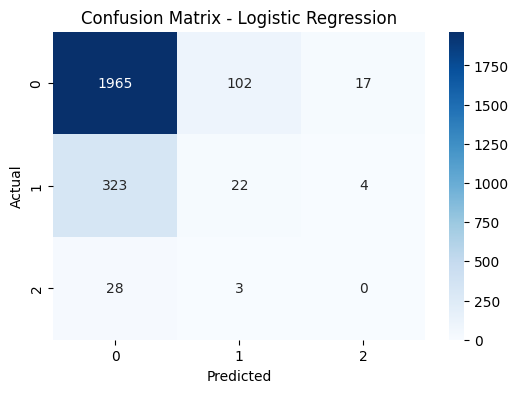

In [42]:
# evaluate function - accuracy + macro f1 + confusion matrix + report
from sklearn.metrics import f1_score

def evaluate_model(name, y_true, y_pred):
    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print("=" * 40)
    print(name)
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    return {"Accuracy": acc, "Macro F1": macro_f1}

results = {}
results["Logistic Regression"] = evaluate_model("Logistic Regression", y_test, y_pred1)


**Evaluate SVC**

SVM
Accuracy : 0.8364
Macro F1 : 0.3724
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      2084
           1       0.31      0.05      0.09       349
           2       0.50      0.06      0.11        31

    accuracy                           0.84      2464
   macro avg       0.55      0.37      0.37      2464
weighted avg       0.77      0.84      0.78      2464



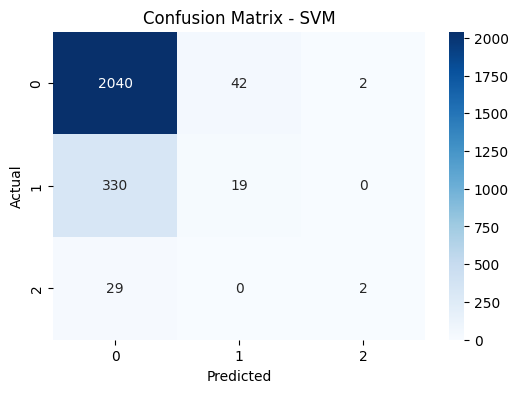

In [43]:
# run on SVM
results["SVM"] = evaluate_model("SVM", y_test, y_pred2)

**Evaluate KNN**

KNN
Accuracy : 0.4671
Macro F1 : 0.3295
              precision    recall  f1-score   support

           0       0.89      0.44      0.59      2084
           1       0.18      0.63      0.28       349
           2       0.07      0.48      0.12        31

    accuracy                           0.47      2464
   macro avg       0.38      0.52      0.33      2464
weighted avg       0.78      0.47      0.54      2464



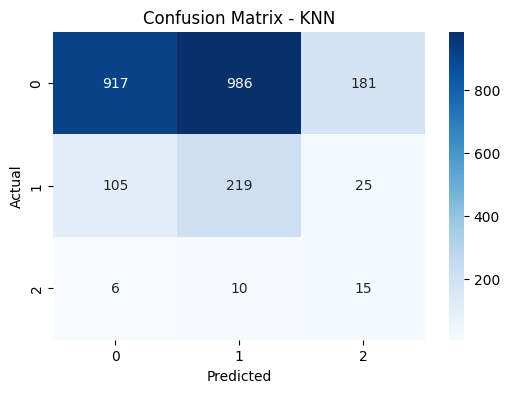

In [44]:
# run on KNN
results["KNN"] = evaluate_model("KNN", y_test, y_pred3)

**Evaluate DecisionTreeClassifier**

Decision Tree
Accuracy : 0.7244
Macro F1 : 0.4118
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      2084
           1       0.23      0.33      0.27       349
           2       0.10      0.19      0.13        31

    accuracy                           0.72      2464
   macro avg       0.40      0.44      0.41      2464
weighted avg       0.77      0.72      0.74      2464



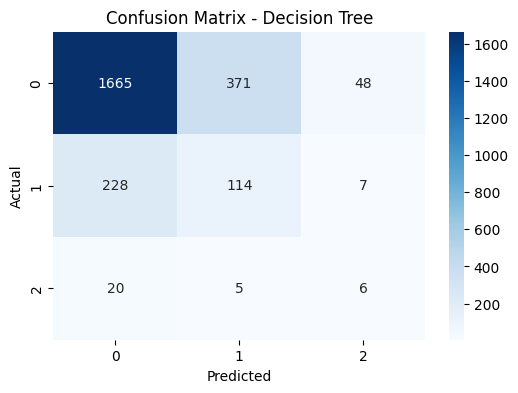

In [45]:
# run on decision tree
results["Decision Tree"] = evaluate_model("Decision Tree", y_test, y_pred4)

**Evaluate RandomForest**

Random Forest
Accuracy : 0.8385
Macro F1 : 0.4640
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2084
           1       0.40      0.14      0.21       349
           2       0.83      0.16      0.27        31

    accuracy                           0.84      2464
   macro avg       0.70      0.42      0.46      2464
weighted avg       0.80      0.84      0.80      2464



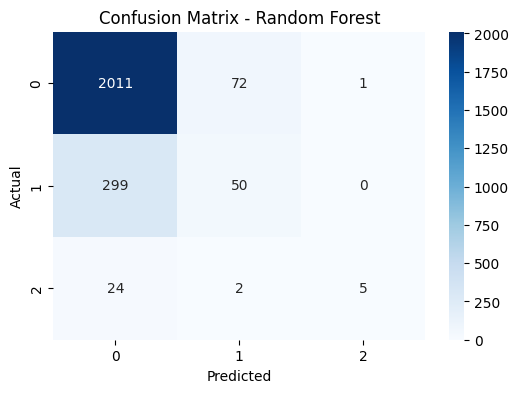

In [46]:
# run on random forest
results["Random Forest"] = evaluate_model("Random Forest", y_test, y_pred5)

**Evaluate XGBoost**

XGBoost
Accuracy : 0.8239
Macro F1 : 0.4527
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      2084
           1       0.32      0.15      0.20       349
           2       0.62      0.16      0.26        31

    accuracy                           0.82      2464
   macro avg       0.60      0.42      0.45      2464
weighted avg       0.78      0.82      0.79      2464



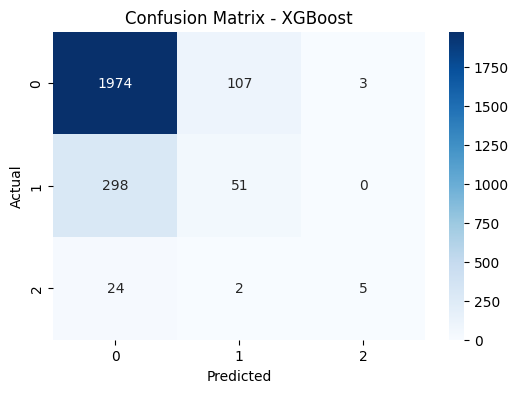

In [47]:
# run on xgboost
results["XGBoost"] = evaluate_model("XGBoost", y_test, y_pred6)

## Compare Models

In [48]:
# compare all models
results_df = pd.DataFrame([
    {"Model": name, "Accuracy": vals["Accuracy"], "Macro F1": vals["Macro F1"]}
    for name, vals in results.items()
]).sort_values(by=["Macro F1", "Accuracy"], ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

best_model_name = results_df.loc[0, "Model"]
print("\nBest Model:", best_model_name)


              Model  Accuracy  Macro F1
      Random Forest  0.838474  0.464018
            XGBoost  0.823864  0.452724
      Decision Tree  0.724432  0.411771
                SVM  0.836445  0.372358
                KNN  0.467127  0.329477
Logistic Regression  0.806412  0.328540

Best Model: Random Forest


# **Hyperparameter Tuning (GridSearchCV)**

Tuning: Random Forest
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.9422267406662606
Random Forest (Tuned)
Accuracy : 0.8385
Macro F1 : 0.4640
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2084
           1       0.40      0.14      0.21       349
           2       0.83      0.16      0.27        31

    accuracy                           0.84      2464
   macro avg       0.70      0.42      0.46      2464
weighted avg       0.80      0.84      0.80      2464



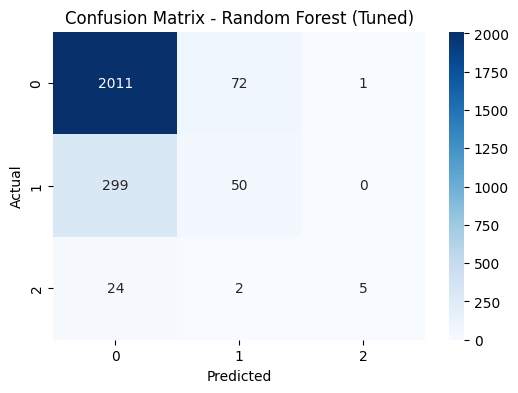

In [49]:
# tune best model with grid search
param_grids = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["lbfgs", "liblinear"]
        }
    },
    "SVM": {
        "estimator": SVC(),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"]
        }
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [5, 10, 20, None],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5]
        }
    },
    "XGBoost": {
        "estimator": XGBClassifier(random_state=42, eval_metric="mlogloss"),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 6, 10],
            "learning_rate": [0.05, 0.1, 0.3]
        }
    }
}

results_df = pd.DataFrame([
    {"Model": name, "Accuracy": vals["Accuracy"]}
    for name, vals in results.items()
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

best_model_name = results_df.loc[0, "Model"]
print("Tuning:", best_model_name)

grid = GridSearchCV(
    estimator=param_grids[best_model_name]["estimator"],
    param_grid=param_grids[best_model_name]["params"],
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_tuned_model = grid.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test)
results[best_model_name + " (Tuned)"] = evaluate_model(best_model_name + " (Tuned)", y_test, y_pred_tuned)

## Evaluation of Tuning

Model: Random Forest
Accuracy  — Before: 0.8385  After: 0.8385  Diff: +0.0000
Macro F1  — Before: 0.4640  After: 0.4640  Diff: +0.0000


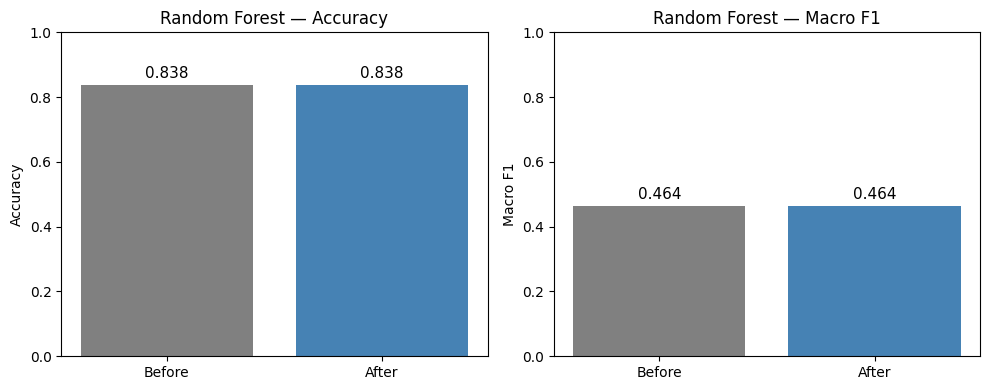

In [50]:
# before vs after tuning
original_acc = results[best_model_name]["Accuracy"]
tuned_acc    = results[best_model_name + " (Tuned)"]["Accuracy"]
improvement  = tuned_acc - original_acc

original_f1 = results[best_model_name]["Macro F1"]
tuned_f1    = results[best_model_name + " (Tuned)"]["Macro F1"]

print("Model:", best_model_name)
print(f"Accuracy  — Before: {original_acc:.4f}  After: {tuned_acc:.4f}  Diff: {improvement:+.4f}")
print(f"Macro F1  — Before: {original_f1:.4f}  After: {tuned_f1:.4f}  Diff: {tuned_f1-original_f1:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric, before, after in [
    (axes[0], "Accuracy", original_acc, tuned_acc),
    (axes[1], "Macro F1", original_f1, tuned_f1)
]:
    ax.bar(["Before", "After"], [before, after], color=["gray", "steelblue"])
    ax.set_ylim(0, 1)
    ax.set_title(f"{best_model_name} — {metric}")
    ax.set_ylabel(metric)
    for i, v in enumerate([before, after]):
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()


# **Deep Learning (ANN)**

## Build Model

In [51]:
# build ANN architecture
num_classes = y_train.nunique()
input_dim = X_train.shape[1]

ann_model = Sequential([
    Dense(128, activation="relu", input_dim=input_dim),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        11,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,571 (84.26 KB)

 Trainable params: 21,571 (84.26 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [52]:
# train ANN - use class_weight since ANN doesnt benefit from SMOTE the same way
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7086 - loss: 0.6732 - val_accuracy: 0.8116 - val_loss: 0.4455
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8215 - loss: 0.4609 - val_accuracy: 0.8582 - val_loss: 0.3529
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8515 - loss: 0.3927 - val_accuracy: 0.8916 - val_loss: 0.2671
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8707 - loss: 0.3473 - val_accuracy: 0.9902 - val_loss: 0.0524
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8791 - loss: 0.3251 - val_accuracy: 0.9794 - val_loss: 0.0895
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8882 - loss: 0.3033 - val_accuracy: 0.9864 - val_loss: 0.0575
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8927 - loss: 0.2899 - val_accuracy: 0.9812 - val_loss: 0.0741
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8965 - loss: 0.2773 - val_accu

## Training Curves

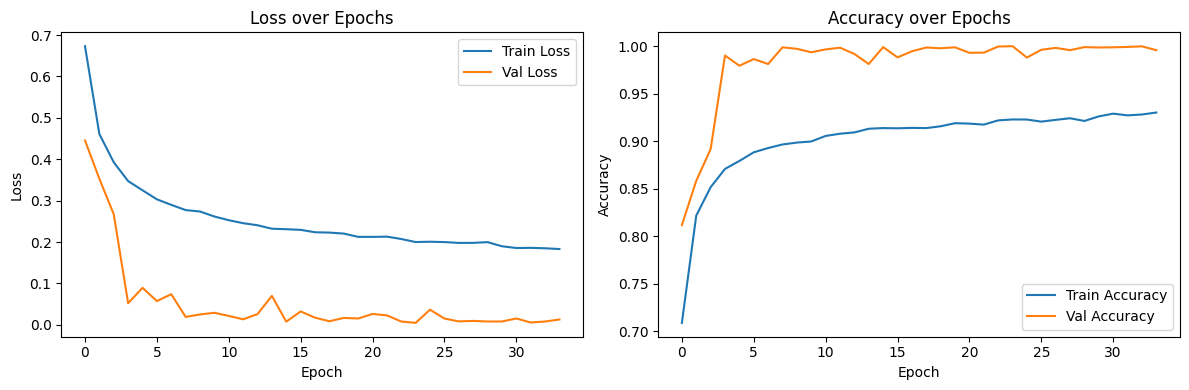

In [53]:
# plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluate ANN

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ANN
Accuracy : 0.8109
Macro F1 : 0.4124
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      2084
           1       0.27      0.13      0.18       349
           2       0.22      0.13      0.16        31

    accuracy                           0.81      2464
   macro avg       0.45      0.40      0.41      2464
weighted avg       0.77      0.81      0.78      2464



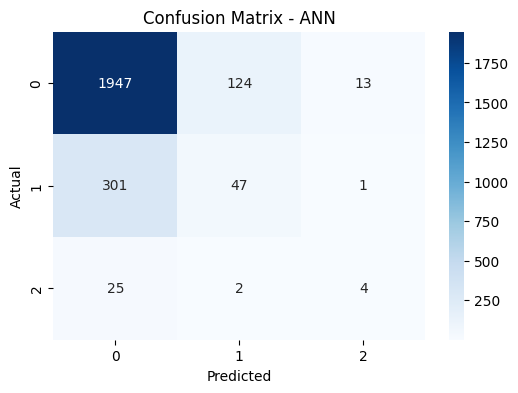

In [54]:
# evaluate ANN
y_pred_ann_prob = ann_model.predict(X_test)
y_pred_ann = np.argmax(y_pred_ann_prob, axis=1)

results["ANN"] = evaluate_model("ANN", y_test, y_pred_ann)

## Update Comparison Table

                Model  Accuracy  Macro F1
        Random Forest  0.838474  0.464018
Random Forest (Tuned)  0.838474  0.464018
              XGBoost  0.823864  0.452724
                  ANN  0.810877  0.412359
        Decision Tree  0.724432  0.411771
                  SVM  0.836445  0.372358
                  KNN  0.467127  0.329477
  Logistic Regression  0.806412  0.328540


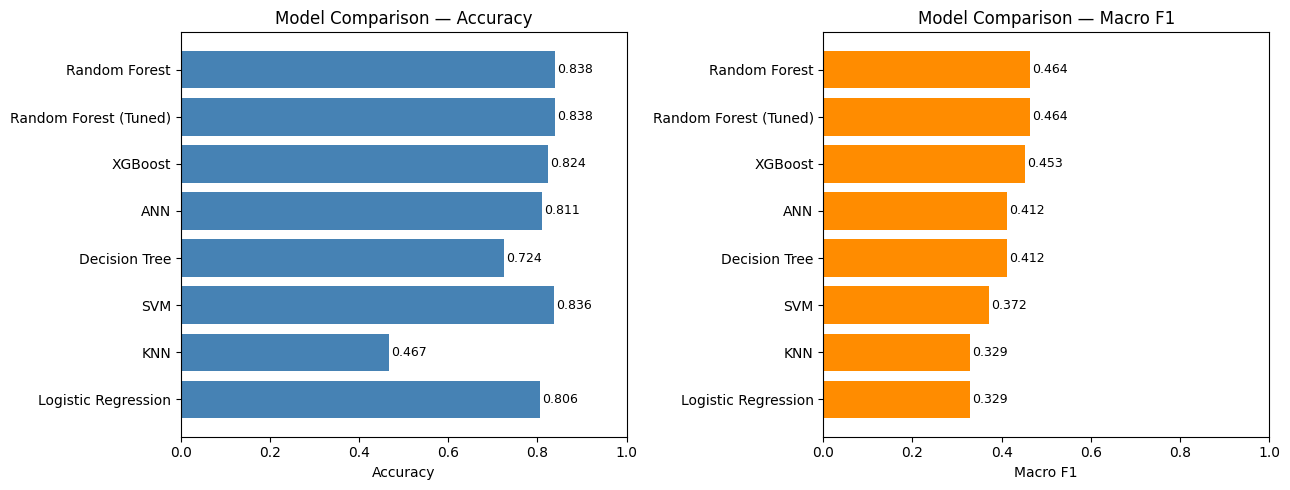


Best Model (by Macro F1): Random Forest


In [55]:
# final comparison with ANN added
results_df = pd.DataFrame([
    {"Model": name, "Accuracy": vals["Accuracy"], "Macro F1": vals["Macro F1"]}
    for name, vals in results.items()
]).sort_values(by=["Macro F1", "Accuracy"], ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

# bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, color in [
    (axes[0], "Accuracy", "steelblue"),
    (axes[1], "Macro F1", "darkorange")
]:
    ax.barh(results_df["Model"][::-1], results_df[col][::-1], color=color)
    ax.set_xlabel(col)
    ax.set_title(f"Model Comparison — {col}")
    ax.set_xlim(0, 1)
    for i, v in enumerate(results_df[col][::-1]):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

best_model_name = results_df.loc[0, "Model"]
print("\nBest Model (by Macro F1):", best_model_name)


# **Feature Importance (Random Forest)**

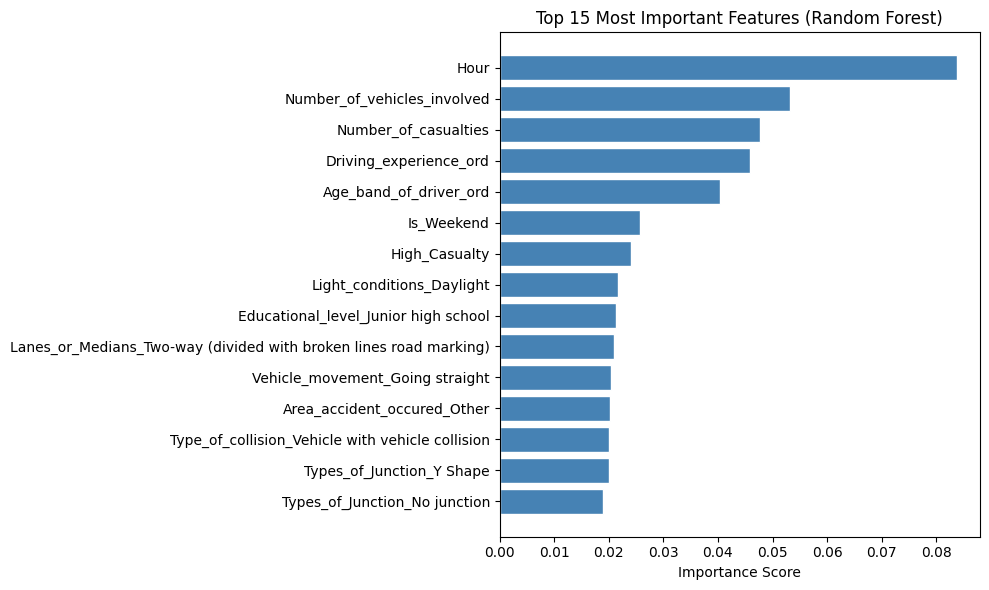

                                                          Feature  Importance
                                                             Hour    0.083824
                                      Number_of_vehicles_involved    0.053277
                                             Number_of_casualties    0.047689
                                           Driving_experience_ord    0.045932
                                           Age_band_of_driver_ord    0.040461
                                                       Is_Weekend    0.025750
                                                    High_Casualty    0.024088
                                        Light_conditions_Daylight    0.021622
                             Educational_level_Junior high school    0.021395
Lanes_or_Medians_Two-way (divided with broken lines road marking)    0.021014
                                  Vehicle_movement_Going straight    0.020418
                                      Area_accident_occured_Othe

In [56]:
# which features matter most?
importances = model5.feature_importances_
feature_names = X_train.columns.tolist()

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color='steelblue', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))

# **Save Model for Deployment**

In [60]:
# save the trained model + scaler for the streamlit app
import joblib

deployment_bundle = {
    "model": best_tuned_model,
    "scaler": scaler,
    "feature_columns": X_train.columns.tolist(),
    "num_cols": num_cols,
    "model_name": best_model_name + " (Tuned)"
}

joblib.dump(deployment_bundle, "roadguard_model.joblib", compress=3)

print("saved   :", "roadguard_model.joblib")
print("model   :", deployment_bundle["model_name"])
print("features:", len(deployment_bundle["feature_columns"]))
print("scaled  :", deployment_bundle["num_cols"])

saved   : roadguard_model.joblib
model   : Random Forest (Tuned)
features: 86
scaled  : ['Number_of_vehicles_involved', 'Number_of_casualties', 'Hour', 'Is_Weekend', 'Driving_experience_ord', 'Age_band_of_driver_ord', 'High_Casualty']


In [61]:
# download the file to your computer
from google.colab import files
files.download("roadguard_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>